In [ ]:
import numpy as np
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
random.seed(42)
np.random.seed(42)

TRAIN_DIR      = Path('/content/drive/MyDrive/sur_project/data/train')
TARGET_DIRS    = [TRAIN_DIR / 'target_train',     TRAIN_DIR / 'target_dev']
NONTARGET_DIRS = [TRAIN_DIR / 'non_target_train', TRAIN_DIR / 'non_target_dev']
MODEL_DIR      = Path('/content/drive/MyDrive/sur_project/face_model')
MODEL_DIR.mkdir(exist_ok=True)

IMG_SIZE = (80, 80)

FOLDS = [
    ('01', ['f401', 'f402', 'f403', 'm414', 'm416', 'm417', 'm419']),
    ('02', ['f404', 'f405', 'f406', 'm420', 'm421', 'm422']),
    ('03', ['f407', 'f408', 'f409', 'm423', 'm424', 'm425']),
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [128]:
class FaceDataset:

    def __init__(self, dirs, label):
        # 1 = target, 0 = non-target
        self.label = label
        # list of (stem, gray_image) RGB is not needed
        self.items = []
        for d in dirs:
            for p in sorted(Path(d).glob('*.png')):
                gray = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
                self.items.append((p.stem, gray))

    def __len__(self):
        return len(self.items)

    def __repr__(self):
        return f'Images of face dataset (label={self.label}, n={len(self)})'

    # Get session where photo of person was taken
    @staticmethod
    def session(stem):
        return stem.split('_')[1]

    # Get person identity (m430, f401 ...)
    @staticmethod
    def identity(stem):
        return stem.split('_')[0]

    # Print sessions and intetities to check
    def print_sess_id(self):
      for stem, gray in self.items:
        identity = self.identity(stem)
        session = self.session(stem)
        print(f"{stem} → Identity: {identity}, Session: {session}")

    # Filtering for subsets in folds
    def filter(self, filter_type, value):
        subset = FaceDataset.__new__(FaceDataset)
        subset.label = self.label
        subset.items = []

        for s, img in self.items:
            keep = False
            # filter for all (tar_train, tar_val, ntar_train, ntar_val)
            if filter_type == 'neq':
                keep = FaceDataset.session(s) != value
            elif filter_type == 'eq':
                keep = FaceDataset.session(s) == value
            elif filter_type == 'person_n_in':
                keep = FaceDataset.identity(s) not in value
            elif filter_type == 'person_in':
                keep = FaceDataset.identity(s) in value
            # Adds only correct stem and image according to fold distribution
            if keep:
                subset.items.append((s, img))

        return subset

    @staticmethod
    def cv_folds(target, nontarget, folds):
        all_folds = []

        for session, people in folds:
            tar_train = target.filter('neq', session)
            tar_val   = target.filter('eq', session)
            nt_train  = nontarget.filter('person_n_in', people)
            nt_val    = nontarget.filter('person_in', people)
            all_folds.append((tar_train, tar_val, nt_train, nt_val))

        return all_folds


target    = FaceDataset(TARGET_DIRS,    label=1)
nontarget = FaceDataset(NONTARGET_DIRS, label=0)

# Check number of labels (targets, nontargets)
print(target)
print(nontarget)

folds = FaceDataset.cv_folds(target, nontarget, FOLDS)

# Check folds
for i, (tar_tr, tar_val, nt_tr, nt_val) in enumerate(folds):
    print(f'Fold {i+1}: tar_train={len(tar_tr)}, tar_val={len(tar_val)} | nt_train={len(nt_tr)}, nt_val={len(nt_val)}')

Images of face dataset (label=1, n=30)
Images of face dataset (label=0, n=192)
Fold 1: tar_train=20, tar_val=10 | nt_train=124, nt_val=68
Fold 2: tar_train=20, tar_val=10 | nt_train=128, nt_val=64
Fold 3: tar_train=20, tar_val=10 | nt_train=132, nt_val=60


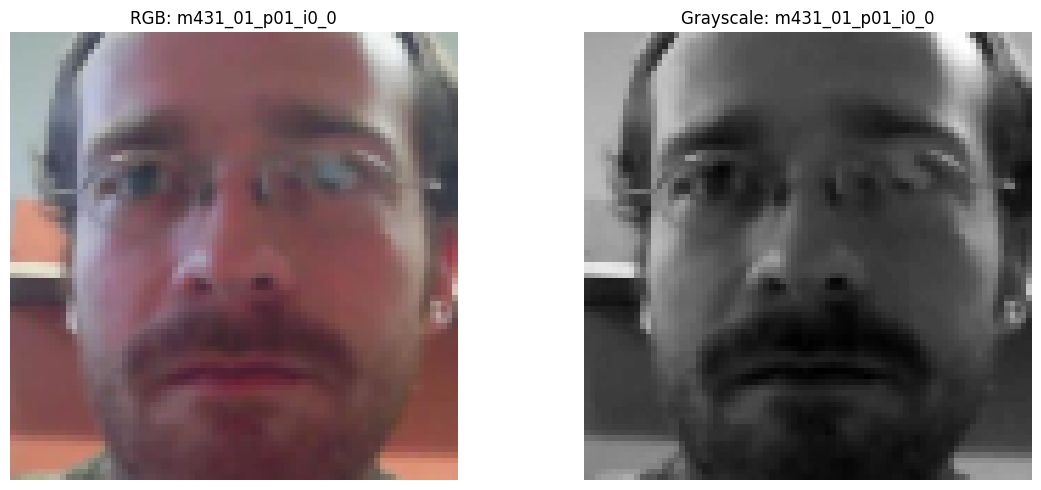

In [129]:
stem, gray_img = target.items[0]

# Original image
original_path = None
for d in TARGET_DIRS:
    for p in sorted(Path(d).glob(f'{stem}.*')):
        original_path = p
        break
    if original_path:
        break

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb_img = cv2.imread(str(original_path), cv2.IMREAD_COLOR)
rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)

axes[0].imshow(rgb_img)
axes[0].set_title(f"RGB: {stem}")
axes[0].axis('off')

# Image is after getting into dataset saved as numpy array with values from 0 - 255 without cmap='gray' is matplotlib showing it as a heatmap so color is greanish
axes[1].imshow(gray_img, cmap='gray')
axes[1].set_title(f"Grayscale: {stem}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from skimage.feature import hog, local_binary_pattern

# Hog
def extract_hog(gray):
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True,
    )


# Lbp
def extract_lbp(gray):
    lbp = local_binary_pattern(gray, P=16, R=2, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=18, range=(0, 18), density=True)
    return hist

# Functions just for the visualizzation
def extract_hog_with_image(gray):
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm='L2-Hys',
        feature_vector=True,
    )

def extract_lbp_with_image(gray):
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    return hist, lbp  # ← Vrátenie oboch!


# def compute_integral_image(gray):
#     return cv2.integral(gray)

# def extract_haar_features(gray):
#     integral = compute_integral_image(gray)
#     features = []

#     h, w = gray.shape
#     for window_size in [4, 8, 16]:
#         for y in range(0, h - window_size, window_size):
#             for x in range(0, w - window_size, window_size):
#                 left = integral[y + window_size, x + window_size // 2] - \
#                        integral[y, x + window_size // 2]
#                 right = integral[y + window_size, x + window_size] - \
#                         integral[y, x + window_size // 2]
#                 features.append(right - left)
#                 top = integral[y + window_size // 2, x + window_size] - \
#                       integral[y, x]
#                 bottom = integral[y + window_size, x + window_size] - \
#                          integral[y + window_size // 2, x]
#                 features.append(bottom - top)
#                 if window_size >= 12:
#                     strip_size = window_size // 3
#                     s1 = integral[y + window_size, x + strip_size] - \
#                          integral[y, x]
#                     s2 = integral[y + window_size, x + 2*strip_size] - \
#                          integral[y, x + strip_size]
#                     s3 = integral[y + window_size, x + window_size] - \
#                          integral[y, x + 2*strip_size]
#                     features.append(s1 - s2 + s3)

#     return np.array(features, dtype=np.float32)

def extract_features(gray):
    # return extract_haar_features(gray)
    return np.concatenate([extract_hog(gray), extract_lbp(gray)])



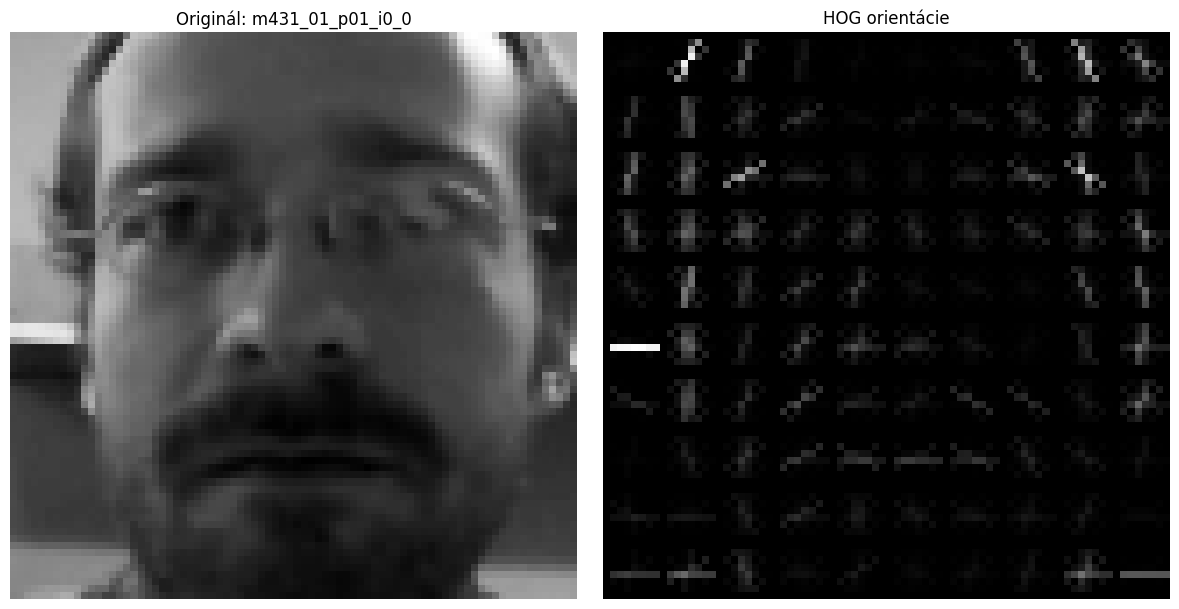

HOG features: 2916


In [ ]:
sample_stem, sample_img = target.items[0]

fd, hog_image = extract_hog_with_image(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Original: {sample_stem}')
axes[0].axis('off')

axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title('HOG orientations')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'HOG features: {len(fd)}')

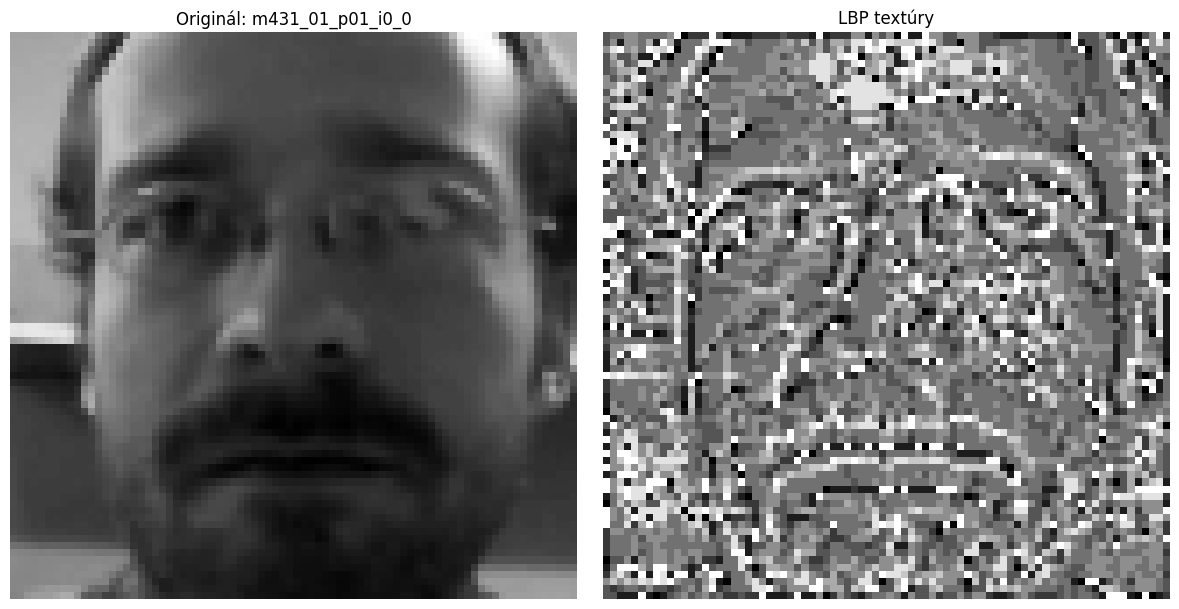

LBP features: 10


In [ ]:
sample_stem, sample_img = target.items[0]

# Vypočítaj LBP
lbp_features, lbp_image = extract_lbp_with_image(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Original: {sample_stem}')
axes[0].axis('off')

axes[1].imshow(lbp_image, cmap='gray')
axes[1].set_title('LBP tectures')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'LBP features: {len(lbp_features)}')

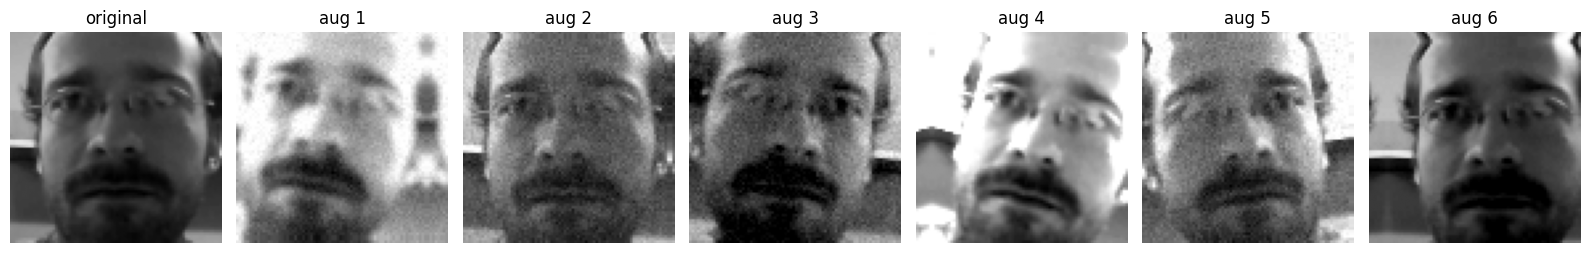

In [ ]:
def augment(gray):
    img = gray.copy().astype(np.float32)

    #  Horizontal flip
    if random.random() < 0.5:
        img = cv2.flip(img, 1)

    # Rotation -25,25
    if random.random() < 0.7:
        angle = random.uniform(-25, 25)
        M = cv2.getRotationMatrix2D((IMG_SIZE[0] / 2, IMG_SIZE[1] / 2), angle, 1.0)
        img = cv2.warpAffine(img, M, IMG_SIZE, borderMode=cv2.BORDER_REFLECT)

    # Contrast and brightness
    if random.random() < 0.8:
        alpha = random.uniform(0.3, 2.5)
        beta  = random.uniform(-60, 60)
        img = np.clip(alpha * img + beta, 0, 255)

    # Gamma correction
    if random.random() < 0.5:
        gamma = random.uniform(0.4, 2.5)
        img = np.clip(np.power(img / 255.0, gamma) * 255.0, 0, 255)

    # Blur
    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        img = cv2.GaussianBlur(img, (ksize, ksize), 0)


    # Gaussian
    if random.random() < 0.5:
        noise = np.random.normal(0, random.uniform(3, 15), img.shape)
        img = np.clip(img + noise, 0, 255)

    # Move
    if random.random() < 0.4:
        tx, ty = random.randint(-8, 8), random.randint(-8, 8)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        img = cv2.warpAffine(img, M, IMG_SIZE, borderMode=cv2.BORDER_REFLECT)

    return img.astype(np.uint8)


# Vizualization
sample_stem, img = target.items[0]

fig, axes = plt.subplots(1, 7, figsize=(16, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('original')
axes[0].axis('off')

for i in range(1, 7):
    axes[i].imshow(augment(img), cmap='gray')
    axes[i].set_title(f'aug {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve


N_AUGS_TARGET    = 15
N_AUGS_NONTARGET =  3
N_PCA_COMPONENTS = 64

# Get Hog and LBP for all images in dataset then do the same for all augmentations
def build_features(dataset, n_augs=0):
    features, labels = [], []
    for _, img in dataset.items:
        features.append(extract_features(img))
        labels.append(dataset.label)
        for _ in range(n_augs):
            features.append(extract_features(augment(img)))
            labels.append(dataset.label)
    return np.array(features), np.array(labels)


def make_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=N_PCA_COMPONENTS, random_state=42)),
        ('svm',    SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced')),
    ])

# Equal error rate
def find_eer(tar_scores, nontar_scores):
    # Get score
    all_scores = np.concatenate([tar_scores, nontar_scores])
    # Get labels
    all_labels = np.concatenate([np.ones(len(tar_scores)), np.zeros(len(nontar_scores))])
    # Get ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    # Get FRR
    frr = 1 - tpr
    # EER where FPR=FRR
    idx = np.argmin(np.abs(fpr - frr))

    return thresholds[idx], fpr[idx]


# Trainng and Cross-validation
all_tar_scores    = []
all_nontar_scores = []

for i, (tar_tr, tar_val, nt_tr, nt_val) in enumerate(FaceDataset.cv_folds(target, nontarget, FOLDS)):
    print(f'Fold {i+1} — training...', end=' ')

    features_train, labels_train = build_features(tar_tr, n_augs=N_AUGS_TARGET)
    features_nt,    labels_nt    = build_features(nt_tr,  n_augs=N_AUGS_NONTARGET)
    features_train = np.vstack([features_train, features_nt])
    labels_train = np.concatenate([labels_train, labels_nt])

    features_val_tar,    _ = build_features(tar_val, n_augs=0)
    features_val_nontar, _ = build_features(nt_val,  n_augs=0)

    pipe = make_pipeline()
    pipe.fit(features_train, labels_train)

    scores_tar    = pipe.predict_proba(features_val_tar)[:, 1]
    scores_nontar = pipe.predict_proba(features_val_nontar)[:, 1]
    all_tar_scores.extend(scores_tar)
    all_nontar_scores.extend(scores_nontar)
    print(f'Finished ({len(features_train)} train)')

all_tar_scores    = np.array(all_tar_scores)
all_nontar_scores = np.array(all_nontar_scores)

threshold, eer = find_eer(all_tar_scores, all_nontar_scores)
print(f'\nEER:                 {eer:.4f}')
print(f'Threshold:           {threshold:.4f}')
print(f'Correct targets:     {np.mean(all_tar_scores > threshold):.3f}')
print(f'Correct non-targets: {np.mean(all_nontar_scores < threshold):.3f}')

Fold 1 — tréning... hotovo (816 train vzoriek)
Fold 2 — tréning... hotovo (832 train vzoriek)
Fold 3 — tréning... hotovo (848 train vzoriek)

EER:                 0.0156
Threshold:           0.0948
Correct targets:     0.967
Correct non-targets: 0.984


In [ ]:
import joblib

# Training on all data after cross validation and savig model
X_all, y_all = build_features(target,    n_augs=N_AUGS_TARGET)
X_nt,  y_nt  = build_features(nontarget, n_augs=N_AUGS_NONTARGET)
X_all = np.vstack([X_all, X_nt])
y_all = np.concatenate([y_all, y_nt])

print(f'Whole train set: {np.sum(y_all==1)} target, {np.sum(y_all==0)} non-target')

final_pipe = make_pipeline()
final_pipe.fit(X_all, y_all)

joblib.dump(final_pipe, MODEL_DIR / 'model.pkl')

with open(MODEL_DIR / 'threshold.txt', 'w') as f:
    f.write(str(threshold))

print(f'Model saved to {MODEL_DIR}/')
print(f'Threshold: {threshold:.6f}')

Celkový train set: 480 target, 768 non-target
Model uložený do /content/drive/MyDrive/sur_project/face_model/
Threshold: 0.094828


In [ ]:
def run_inference(eval_dir, output_file='image_results.txt'):
    pipe = joblib.load(MODEL_DIR / 'model.pkl')
    with open(MODEL_DIR / 'threshold.txt') as f:
        thr = float(f.read())

    results = []
    for p in sorted(Path(eval_dir).glob('*.png')):
        gray  = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        feats = extract_features(gray).reshape(1, -1)
        score = pipe.predict_proba(feats)[0, 1]
        decision = 1 if score > thr else 0
        results.append(f'{p.stem} {score:.6f} {decision}')

    with open(output_file, 'w') as f:
        f.write('\n'.join(results) + '\n')

    n_target = sum(1 for r in results if r.endswith('1'))
    print(f'Processed: {len(results)} files')
    print(f'Decision 1 (target):     {n_target}')
    print(f'Decision 0 (non-target): {len(results) - n_target}')
    print(f'Results saved to: {output_file}')

EVAL_DIR = Path('PATH')
run_inference(EVAL_DIR, output_file='image_HOG_LBP_SVM.txt')

Spracovaných: 0 súborov
Rozhodnutie 1 (target):     0
Rozhodnutie 0 (non-target): 0
Výsledky uložené do: image_HOG_LBP_SVM.txt


In [ ]:
def evaluate(results_file, ground_truth_file):
    gt = {}
    with open(ground_truth_file) as f:
        for line in f:
            parts = line.strip().split()
            gt[parts[0]] = int(parts[1])

    scores_tar, scores_nontar = [], []
    correct, total = 0, 0

    with open(results_file) as f:
        for line in f:
            parts = line.strip().split()
            stem, score, decision = parts[0], float(parts[1]), int(parts[2])
            if stem not in gt:
                continue
            label = gt[stem]
            if label == 1:
                scores_tar.append(score)
            else:
                scores_nontar.append(score)
            correct += (decision == label)
            total   += 1

    scores_tar    = np.array(scores_tar)
    scores_nontar = np.array(scores_nontar)
    _, eer = find_eer(scores_tar, scores_nontar)

    print(f'Overall:          {total} súborov')
    print(f'Target:           {len(scores_tar)}, Non-target: {len(scores_nontar)}')
    print(f'Accuracy:         {correct/total:.4f}  ({correct}/{total})')
    print(f'EER:              {eer:.4f}')
    print(f'Correct targets:     {np.mean(scores_tar > threshold):.3f}  ({np.sum(scores_tar > threshold)}/{len(scores_tar)})')
    print(f'Correct non-targets: {np.mean(scores_nontar < threshold):.3f}  ({np.sum(scores_nontar < threshold)}/{len(scores_nontar)})')


evaluate('image_HOG_LBP_SVM.txt', 'PATH')

FileNotFoundError: [Errno 2] No such file or directory: 'PATH'